# Using GLT to analyse basic gurobi logs on tests and to final instances 

## Libs

In [ ]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import gurobi_logtools as glt 
import glob
import seaborn as sns
import re



## Data

In [ ]:
log_files = glob.glob("logs_sparse/*.log", recursive=True)
results = glt.parse(log_files)
summary = results.summary()
nodelog_progress = results.progress("nodelog")


In [52]:
summary['blocks'] = summary['LogFilePath'].str.extract(r'(\d+)B').astype(float)
summary['fronts'] = summary['LogFilePath'].str.extract(r'(\d+)F').astype(float)
summary['gamma']  = summary['LogFilePath'].str.extract(r'gamma_(\d+d\d+)')[0].str.replace('d', '.').astype(float)
summary['theta']  = summary['LogFilePath'].str.extract(r'theta(\d+d\d+)')[0].str.replace('d', '.').astype(float)
summary['gamma'] = summary['gamma'].fillna(0)
summary.head(5)

,Platform,Time,PhysicalCores,LogicalProcessors,Threads,NumConstrs,NumVars,NumNZs,Fingerprint,PresolvedNumConVars,...,Cuts: Implied bound,LogFile (Parameter),MIPGap (Parameter),OptimalityTol (Parameter),Seed,Version,blocks,fronts,gamma,theta
0,linux64,2026-03-21 12:08:48,4,8,8,59720,1530110,4609662,0x44259498,5940,...,NaN,"""logs_fast/100B_3F_deterministic_2026-03-21_12...",0.005,0.005,0,13.0.1,100.0,3.0,0.00,NaN
1,linux64,2026-03-22 01:59:24,4,8,8,60721,1531121,4635098,0x9ecd5d79,6446,...,NaN,"""logs/100B_3F_robust_gamma_0d25_theta_0d051999...",0.005,0.005,0,13.0.1,100.0,3.0,0.25,NaN
2,linux64,2026-03-22 03:03:32,4,8,8,60721,1531121,4635098,0xe2af3859,6446,...,NaN,"""logs/100B_3F_robust_gamma_0d5_theta_0d0519999...",0.005,0.005,0,13.0.1,100.0,3.0,0.50,NaN
3,linux64,2026-03-22 04:07:44,4,8,8,60721,1531121,4635098,0x61ef1ae8,6446,...,NaN,"""logs/100B_3F_robust_gamma_0d75_theta_0d051999...",0.005,0.005,0,13.0.1,100.0,3.0,0.75,NaN
4,linux64,2026-03-22 13:38:43,4,8,8,60721,1531121,4635098,0x0c16ee9f,6446,...,NaN,"""logs/100B_3F_robust_gamma_1_theta_0d051999999...",0.005,0.005,0,13.0.1,100.0,3.0,1.00,NaN


## Plots

#### Solution data 

In [53]:
plot_name = 1
for inst in summary['LogFilePath'].unique():
    inst_progress = nodelog_progress[nodelog_progress['LogFilePath'] == inst]

    plt.Figure(figsize=(3,4))
    sns.lineplot(inst_progress,x='Time',y='BestBd')
    sns.lineplot(inst_progress,x='Time',y='Incumbent')
    #plot_name = f'{inst_progress['blocks']}B_{inst_progress['fronts']}F_{inst_progress['gamma']}gamma'
    plt.title(plot_name)
    plt.savefig(f'convergence/{plot_name}.png')
    
    plt.clf() 
    plot_name += 1


<Figure size 640x480 with 0 Axes>

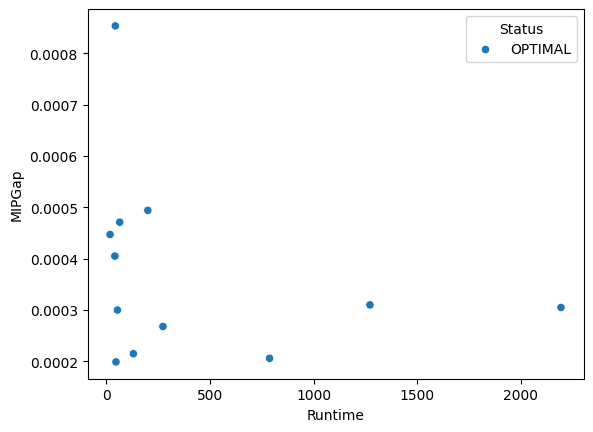

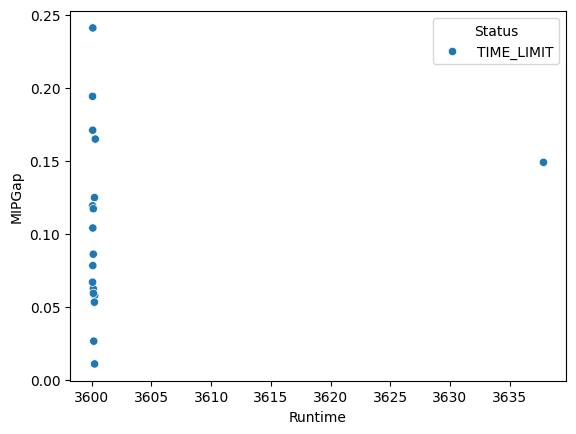

In [54]:
sns.scatterplot(summary[summary['Runtime'] < 2500],x='Runtime',y='MIPGap',hue = 'Status',palette='tab10')
plt.show()

sns.scatterplot(summary[summary['Runtime'] > 2500],x='Runtime',y='MIPGap', hue = 'Status',palette='tab10')
plt.show()

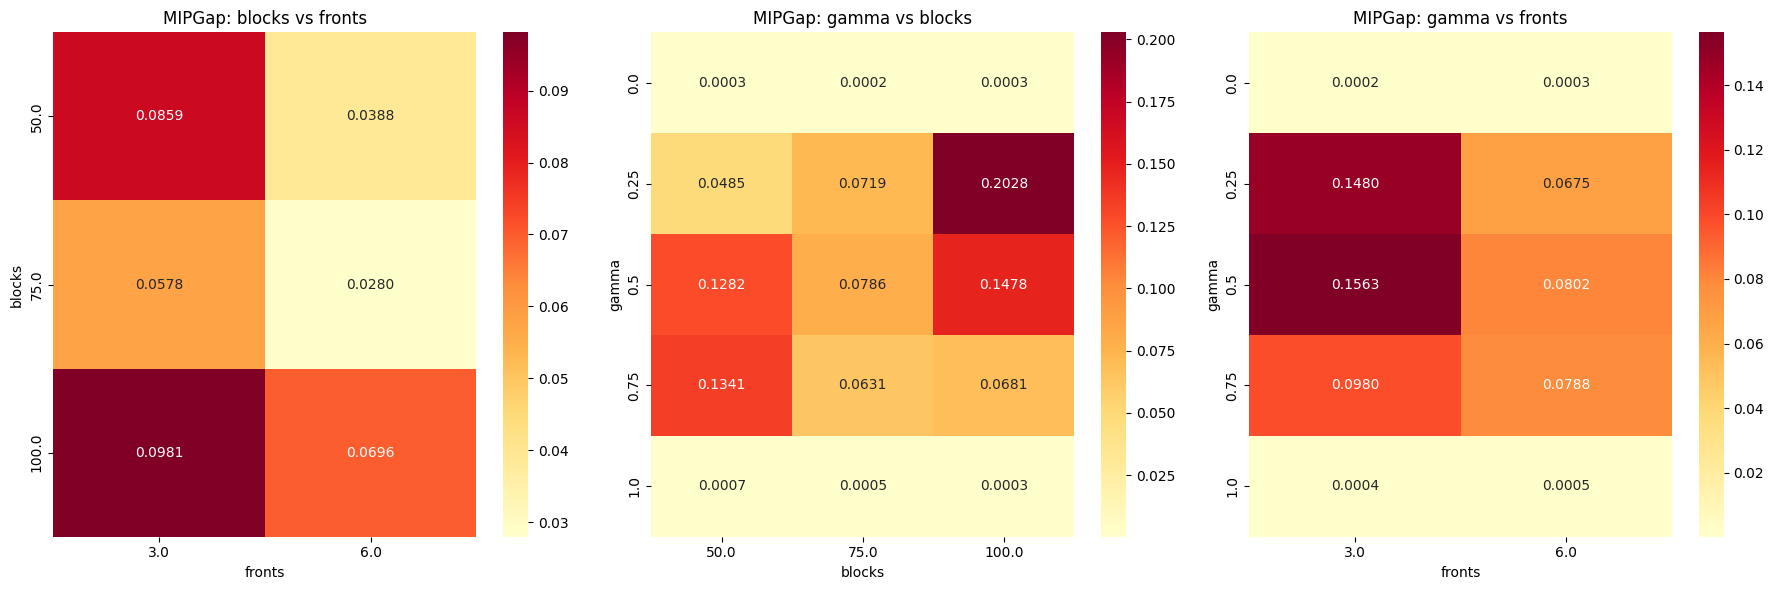

In [55]:
heatmaps = [
    ('blocks', 'fronts'),
    ('gamma', 'blocks'),
    ('gamma', 'fronts'),]

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, (row, col) in zip(axes.flatten(), heatmaps):
    pivot = summary.pivot_table(values='MIPGap', index=row, columns=col, aggfunc='mean')
    sns.heatmap(pivot, annot=True, fmt='.4f', cmap='YlOrRd', ax=ax)
    ax.set_title(f'MIPGap: {row} vs {col}')

plt.tight_layout()
plt.show()

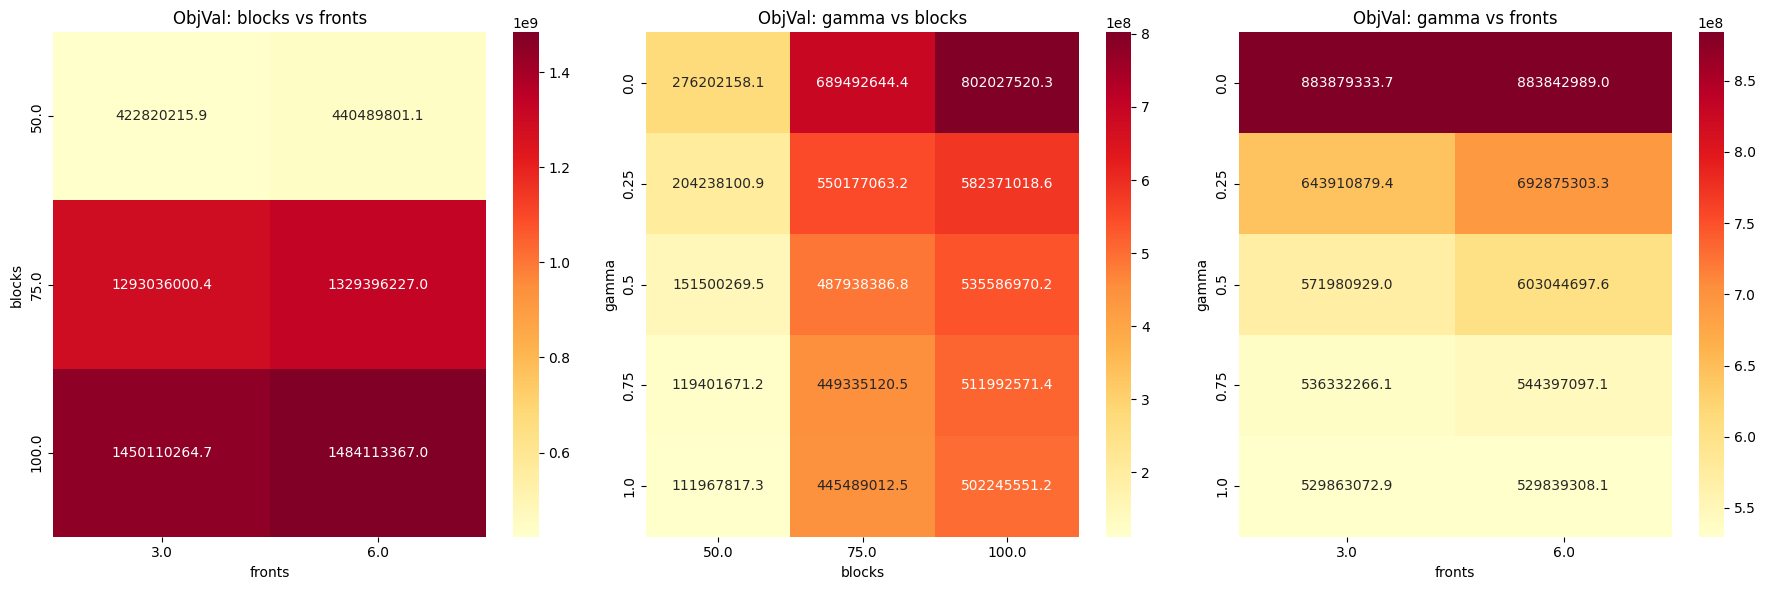

In [56]:
heatmaps = [
    ('blocks', 'fronts'),
    ('gamma', 'blocks'),
    ('gamma', 'fronts'),]

summary['ObjVal'] = summary['ObjVal']

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for ax, (row, col) in zip(axes.flatten(), heatmaps):
    pivot = summary.pivot_table(values='ObjVal', index=row, columns=col, aggfunc='sum')
    sns.heatmap(pivot, annot=True, fmt='.1f', cmap='YlOrRd', ax=ax)
    ax.set_title(f'ObjVal: {row} vs {col}')

plt.tight_layout()
plt.show()